# Cardiovascular Disease Risk Prediction — Notebook 2
**  Notebook 2  input is Notebook 1 i.e. Data Ceaning Notebook **

## Data Preparation, Feature Engineering & Baseline Model Training

**Project:** Cardiovascular Disease Risk Screening System  
**Task:** Binary Classification — Disease / No Disease  
**Dataset:** Cardiovascular Disease Dataset — Kaggle  
**Records after cleaning:** 62,499  
**Original records:** 70,000

---

##  Objective

Prepare the cleaned cardiovascular disease dataset for machine learning by performing **data validation, feature engineering, feature preparation, train/test splitting, and baseline model training**.

The baseline models used in this notebook are:

- **Logistic Regression**
- **Random Forest**
- **XGBoost**

---

##  Notebook Workflow

| Step | What You Do | What You Achieve |
|---|---|---|
| 1 | Load cleaned data | Work with the validated dataset |
| 2 | Data validation | Confirm missing values, duplicates and data types |
| 3 | Feature Engineering | Create meaningful features such as **Age in Years** and **BMI** |
| 4 | Feature Preparation | Separate input features and the binary target |
| 5 | Train/Test Split | Create a **stratified 80/20 split** |
| 6 | Baseline Model Training | Train Logistic Regression, Random Forest and XGBoost |
| 7 | Baseline Evaluation | Compare Accuracy, Precision, Recall, F1 and ROC-AUC |
| 8 | Save Processed Data | Prepare data for advanced model optimization in Notebook 2 |

---

##  Feature Engineering

The following transformations will be performed:

- Convert **age from days to years**
- Calculate **BMI** from height and weight
- Remove the non-predictive **ID** column
- Prepare the remaining clinical features for model training

### BMI Formula

$$
BMI = \frac{Weight\ (kg)}{Height\ (m)^2}
$$

---

##  Baseline Models

Three classification algorithms will be trained:

1. **Logistic Regression** — interpretable linear baseline
2. **Random Forest** — ensemble tree-based model
3. **XGBoost** — gradient boosting model

These models will provide a **baseline performance** before hyperparameter optimization.

---

> **Why separate baseline training from optimization?**

> This notebook focuses on building a **clean and reliable baseline pipeline**. Advanced optimization techniques such as **GridSearchCV, hyperparameter tuning, detailed model comparison, and decision-threshold tuning for high recall** will be performed separately in **Notebook 2**.

---

##  Expected Output

At the end of this notebook, we will have:

- ✅ Model-ready features
- ✅ Stratified training and testing datasets
- ✅ Three trained baseline models
- ✅ Baseline performance comparison
- ✅ Processed datasets ready for Notebook 2

### Next Step

**Notebook 2 → Model Optimization & Evaluation**

`GridSearchCV → Hyperparameter Tuning → ROC-AUC → Confusion Matrix → Threshold Tuning → High Recall → Final Model Selection`

In [53]:
# RAW DATA — 70,000 records
#         ↓
# Data Ingestion
#         ↓
# Outlier Detection + Removal
#         ↓
# 62,499 records
#         ↓
# Remaining Data Cleaning
#   ├── Missing values        → 0
#   ├── Duplicate rows        → 0
#   ├── Duplicate IDs         → 0
#   ├── Invalid cholesterol   → 0
#   ├── Invalid glucose       → 0
#   └── Data types validated
#         ↓
# cardio_final_cleaned.csv ✅
#         ↓


# 🔥🔥🔥🔥🔥🔥🔥 WE ARE HERE  🔥🔥🔥🔥🔥🔥🔥 
#                      ↓



# Cleaned Dataset
#       ↓
# Data Validation
#       ↓
# Feature Engineering
#    ├── Age → Years
#    └── BMI
#       ↓
# Feature Preparation
#       ↓
# Stratified Train/Test Split
#       ↓
# Baseline Model Training
#    ├── Logistic Regression
#    ├── Random Forest
#    └── XGBoost
#       ↓
# Baseline Evaluation
#       ↓
# Processed Data
#       ↓
# Notebook 3
#       ↓
# GridSearchCV + Threshold Tuning

**cardio_final_cleaned.csv
        ↓
Feature Engineering
        ↓
Encoding
        ↓
X / y
        ↓
Train/Test Split (stratified)
        ↓
Baseline Models
 ├── Logistic Regression
 ├── Random Forest
 └── XGBoost
        ↓
Basic baseline metrics**

In [54]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [55]:
# ============================================================
# 2. LOAD CLEANED DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/alkaraikbar/cleaned-dataset/cardio_final_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (62499, 13)


In [56]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.4,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.4,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.7,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.3,2,169,82.0,150,100,1,1,0,0,1,1
4,8,60.0,1,151,67.0,120,80,2,2,0,0,0,0



Dataset shape:
(62499, 13)

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:


id               int64
age            float64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


Missing values:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


Duplicate rows:
0


In [57]:
# ============================================================
# 4. TARGET DISTRIBUTION
# ============================================================

print("Target distribution:")
display(df["cardio"].value_counts())

print("\nTarget percentage:")
display(df["cardio"].value_counts(normalize=True) * 100)

Target distribution:


cardio
0    31631
1    30868
Name: count, dtype: int64


Target percentage:


cardio
0    50.61041
1    49.38959
Name: proportion, dtype: float64

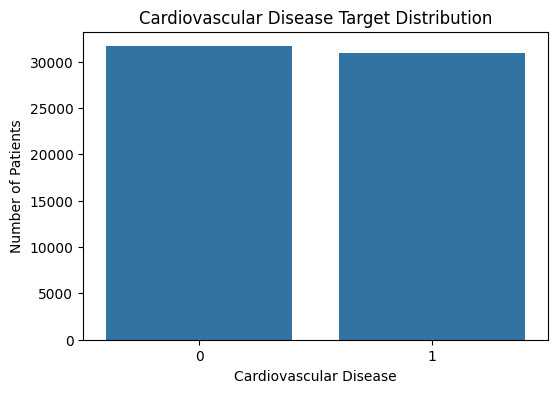

In [58]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cardio")

plt.title("Cardiovascular Disease Target Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")

plt.show()


# Feature Engineering 

#  Feature Engineering


**Yahan BMI aur age in years create karenge.Kaggle cardiovascular dataset mein:age generally days mein hota haiheight cm meinweight kg mein**
# BMI:BMI=    weight/height^2
**where height is converted from cm to meters.**


In [59]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

df_model = df.copy()

# ------------------------------------------------------------
# Age: days -> years
# ------------------------------------------------------------
df_model["age_years"] = (df_model["age"] / 365.25).round(1)

# ------------------------------------------------------------
# BMI calculation
# ------------------------------------------------------------
height_m = df_model["height"] / 100

df_model["BMI"] = (
    df_model["weight"] / (height_m ** 2)
).round(2)

print("Feature engineering completed!")

display(
    df_model[
        ["age", "age_years", "height", "weight", "BMI"]
    ].head()
)






# ============================================================
# 6. CHECK ENGINEERED FEATURES
# ============================================================

print("Age statistics:")
display(df_model["age_years"].describe())

print("\nBMI statistics:")
display(df_model["BMI"].describe())

Feature engineering completed!


,age,age_years,height,weight,BMI
0,50.4,0.1,168,62.0,21.97
1,55.4,0.2,156,85.0,34.93
2,51.7,0.1,165,64.0,23.51
3,48.3,0.1,169,82.0,28.71
4,60.0,0.2,151,67.0,29.38


Age statistics:


count    62499.000000
mean         0.145193
std          0.049769
min          0.100000
25%          0.100000
50%          0.100000
75%          0.200000
max          0.200000
Name: age_years, dtype: float64


BMI statistics:


count    62499.000000
mean        27.120161
std          4.567517
min         13.520000
25%         23.880000
50%         26.230000
75%         29.760000
max         50.890000
Name: BMI, dtype: float64

# Remove Unnecessary Raw Features

In [60]:
# ============================================================
# 7. REMOVE NON-MODEL / REDUNDANT FEATURES
# ============================================================

# ID is an identifier, not a clinical predictor
if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

# Replace raw age in days with age in years
if "age" in df_model.columns:
    df_model = df_model.drop(columns=["age"])

print("Updated columns:")
print(df_model.columns.tolist())

Updated columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI']


# Train/Test Split

In [61]:
# ============================================================
# 8. SEPARATE FEATURES AND TARGET
# ============================================================

TARGET = "cardio"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())







# ============================================================
# 9. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True))

Feature matrix shape: (62499, 12)
Target shape: (62499,)

Features:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'BMI']
Training set: (49999, 12)
Testing set : (12500, 12)

Training target distribution:


cardio
0    0.50611
1    0.49389
Name: proportion, dtype: float64


Testing target distribution:


cardio
0    0.50608
1    0.49392
Name: proportion, dtype: float64

# Baseline Models

In [62]:
# ============================================================
# 10. DEFINE BASELINE MODELS
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgboost_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

print("Baseline models created successfully!")

Baseline models created successfully!


# Train Model

Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.

Training XGBoost...
XGBoost training completed.



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.7200,0.7426,0.6629,0.7005,0.7826
1,Logistic Regression,0.7220,0.7550,0.6472,0.6970,0.7804
2,Random Forest,0.6922,0.6929,0.6767,0.6847,0.7419


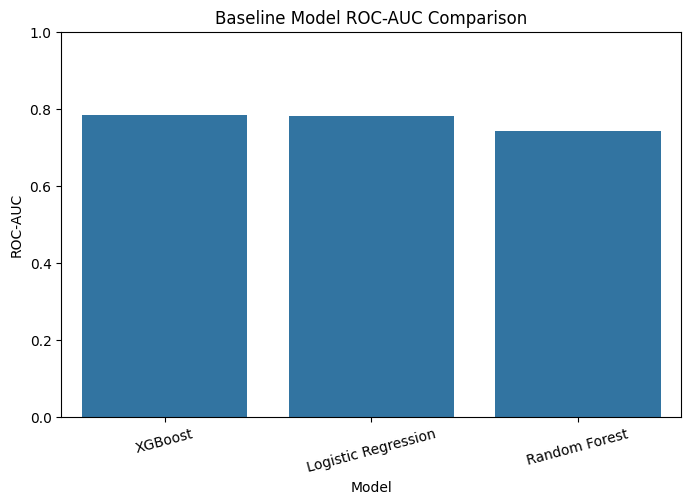

In [63]:
# ============================================================
# 11. TRAIN BASELINE MODELS
# ============================================================

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} training completed.\n")



# ============================================================
# 12. BASELINE MODEL EVALUATION
# ============================================================

baseline_results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(baseline_results_df.round(4))







# ============================================================
# 13. BASELINE ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("Baseline Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()










#  Save Model

In [64]:
# ============================================================
# 14. SAVE PROCESSED TRAIN / TEST DATA
# ============================================================

train_data = X_train.copy()
train_data[TARGET] = y_train.values

test_data = X_test.copy()
test_data[TARGET] = y_test.values

train_data.to_csv(
    "cardio_train_processed.csv",
    index=False
)

test_data.to_csv(
    "cardio_test_processed.csv",
    index=False
)

print("Processed train/test datasets saved successfully!")


# ============================================================
# 15. SAVE FEATURE NAMES
# ============================================================

feature_names = X.columns.tolist()

with open("feature_names.txt", "w") as file:

    for feature in feature_names:
        file.write(feature + "\n")

print("Feature names saved successfully!")

print("\nFinal model features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Processed train/test datasets saved successfully!
Feature names saved successfully!

Final model features:
1. gender
2. height
3. weight
4. ap_hi
5. ap_lo
6. cholesterol
7. gluc
8. smoke
9. alco
10. active
11. age_years
12. BMI


<!-- cardio_final_cleaned.csv
          ↓
       Load Data
          ↓
    Initial Inspection
          ↓
   Feature Engineering
      ├── Age → Years
      └── BMI
          ↓
   Remove ID / raw age
          ↓
      X and y
          ↓
 Stratified Train/Test Split
          ↓
   ┌─────────────────────┐
   │ Logistic Regression │
   │ Random Forest       │
   │ XGBoost             │
   └─────────────────────┘
          ↓
   Baseline Evaluation
          ↓
 Save Processed Data



NOTEBOOK1 OUTPUT--->
<!-- "Data has been transformed into model-ready features and baseline performance has been established for Logistic Regression, Random Forest and XGBoost. -->






 

# Final Notebook Summary

In [65]:
# ============================================================
# 16. NOTEBOOK SUMMARY
# ============================================================

print("=" * 60)
print("NOTEBOOK 1 — DATA PREPARATION & BASELINE")
print("=" * 60)

print(f"Original cleaned dataset records : {len(df):,}")
print(f"Training records                 : {len(X_train):,}")
print(f"Testing records                  : {len(X_test):,}")
print(f"Number of features               : {X.shape[1]}")

print("\nModels trained:")
for model_name in trained_models:
    print(f"  ✓ {model_name}")

print("\nBaseline Results:")
display(baseline_results_df.round(4))

print("\nNext step:")
print("→ Notebook 2: Model Optimization & Evaluation")
print("→ GridSearchCV")
print("→ ROC-AUC comparison")
print("→ Confusion Matrix")
print("→ Threshold tuning for high recall")
print("→ Final model selection")

NOTEBOOK 1 — DATA PREPARATION & BASELINE
Original cleaned dataset records : 62,499
Training records                 : 49,999
Testing records                  : 12,500
Number of features               : 12

Models trained:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost

Baseline Results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.7200,0.7426,0.6629,0.7005,0.7826
1,Logistic Regression,0.7220,0.7550,0.6472,0.6970,0.7804
2,Random Forest,0.6922,0.6929,0.6767,0.6847,0.7419



Next step:
→ Notebook 2: Model Optimization & Evaluation
→ GridSearchCV
→ ROC-AUC comparison
→ Confusion Matrix
→ Threshold tuning for high recall
→ Final model selection


<!-- cardio_final_cleaned.csv
          ↓
       Load Data
          ↓
    Initial Inspection
          ↓
   Feature Engineering
      ├── Age → Years
      └── BMI
          ↓
   Remove ID / raw age
          ↓
      X and y
          ↓
 Stratified Train/Test Split
          ↓
   ┌─────────────────────┐
   │ Logistic Regression │
   │ Random Forest       │
   │ XGBoost             │
   └─────────────────────┘
          ↓
   Baseline Evaluation
          ↓
 Save Processed Data
          ↓
       NOTEBOOK 2 -->